In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from matplotlib import pyplot as plt

# Black-hole binary formation channels with gaussian mixtures.

Many problems in astrophysics give rise to data with multiple modes. This is typically because different processes physical processes contribute to the observed dataset.

For instance, one of the most outstanding question in gravitational-wave astrophysics is the formation channel of binary black holes. Leading scenarions include the evolution of isolated binaries in the galactic field and the dynamica assembly of sources in dense environments like globular clusters.

Right now, state-of-the-art analyses seems to say that many channels are all at play. This is a plot by Zevin et al (2020)

Some events form in different astrophysical environments than others. You want to figure out how many of formation channels are at play.

The strategy here is to fit a Gaussian Mixture model: that is, my model is a sum of N gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$ and weight $\alpha_j$:

$p(x_i|\theta) = \sum_{j=1}^N\alpha_jN(x_i|\mu_j,\sigma_j)$

This depends on 3N-1 parameters (not 3N because the sum of the $\alpha_j$  must be unity to ensure that this is a probability.)

## Task

1. Load this file (np.load) and complete a quick exploration of the data. How many modes do you think you see?

2. We'll use sklearn.mixture.GaussianMixture. You first need to define the model (instance of a class), and then train it on the data using the fit method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

3. Complete the fit 10 times with N = 1,...,10 Gaussians.

Note: sklearn by default will use the so-called Expectation-Maximization algorithm, which is one of the many great things in data science we don't have time to study in this class.

4. For each of these fits, compute the AIC (easy! It's an attribute of the trained model!). Plot N vs AIC: which model is preferred?

5. Plot the preferred solution on top of the input data. You should get a very nice fit!

In [3]:
data = np.load('../solutions/formationchannels.npy')
print(data)

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]]


In [4]:
x = data
print(x, x.shape)
print(x[np.newaxis,:], x[np.newaxis,:].shape)
print(x[:,np.newaxis], x[:,np.newaxis].shape)

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]] (2950, 1)
[[[17.12172682]
  [ 5.94121793]
  [ 6.35914124]
  ...
  [34.34170191]
  [30.27018478]
  [25.93264098]]] (1, 2950, 1)
[[[17.12172682]]

 [[ 5.94121793]]

 [[ 6.35914124]]

 ...

 [[34.34170191]]

 [[30.27018478]]

 [[25.93264098]]] (2950, 1, 1)


(array([  1.,   0.,   1.,   1.,   1.,   0.,   2.,   3.,   2.,   1.,   4.,
          1.,   3.,   7.,   6.,  11.,   4.,  11.,   9.,  15.,  13.,   9.,
         11.,  19.,  19.,  11.,  16.,  17.,  19.,  12.,  14.,  14.,   9.,
         15.,  13.,   4.,  12.,  10.,   3.,   5.,   8.,  14.,  23.,  40.,
         72., 117., 145., 129., 104.,  51.,  38.,  26.,  48.,  44.,  47.,
         47.,  51.,  73.,  59.,  80.,  69.,  75.,  78.,  85.,  82.,  88.,
         86.,  84.,  80.,  71.,  87.,  58.,  57.,  65.,  49.,  48.,  32.,
         33.,  32.,  26.,  34.,  17.,  15.,  14.,  11.,  12.,   2.,   6.,
          0.,   1.,   2.,   2.,   2.,   0.,   1.,   0.,   0.,   1.,   0.,
          1.]),
 array([-4.965425  , -4.42875831, -3.89209161, -3.35542492, -2.81875822,
        -2.28209152, -1.74542483, -1.20875813, -0.67209144, -0.13542474,
         0.40124195,  0.93790865,  1.47457534,  2.01124204,  2.54790873,
         3.08457543,  3.62124212,  4.15790882,  4.69457551,  5.23124221,
         5.7679089 ,  6.30

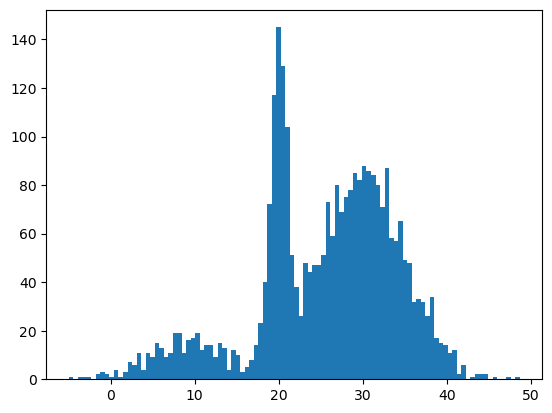

In [5]:
plt.hist(data, bins = 100)

In [6]:
from sklearn.mixture import GaussianMixture

gauss_mix = GaussianMixture(n_components=3, random_state=0)

In [7]:
fit = gauss_mix.fit(data)
print(gauss_mix.means_)        
print(gauss_mix.covariances_)  
print(gauss_mix.weights_)      

[[30.12430964]
 [20.05198472]
 [ 9.09213997]]
[[[24.11386033]]

 [[ 1.13730617]]

 [[21.79683296]]]
[0.66935985 0.21440586 0.11623429]


In [8]:
models = []
mean_arr = []
cov_arr = []
aic = []

for n in range(1, 11):
    mix = GaussianMixture(n_components=n, random_state=0)
    mix.fit(data)
    
    models.append(mix)
    mean_arr.append(mix.means_)
    cov_arr.append(mix.covariances_)
    aic.append(mix.aic(data))

print(aic)

[np.float64(20945.9726085902), np.float64(20754.158751877432), np.float64(20083.309155309096), np.float64(20101.60043333141), np.float64(20114.095745675375), np.float64(20122.766659116474), np.float64(20131.590157331997), np.float64(20128.15439190298), np.float64(20134.03432161794), np.float64(20141.90627310284)]


In [9]:
print('indice:', np.argmin(aic)+1)
print('AIC: ', np.min(aic))

indice: 3
AIC:  20083.309155309096


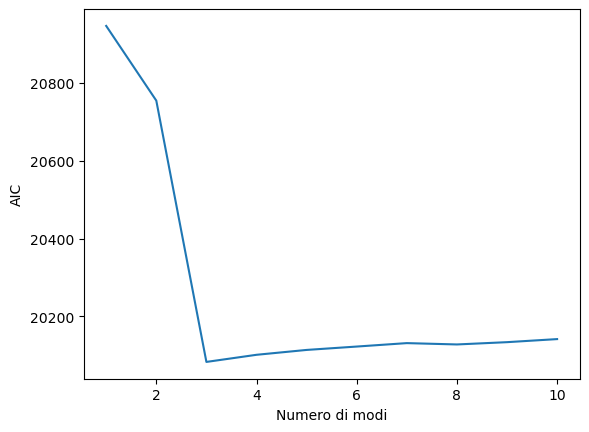

In [27]:
x = np.linspace(1,10,10)
plt.plot(x, aic)
plt.xlabel('Numero di modi')
plt.ylabel('AIC')

best = models[np.argmin(aic)+1]

(1000, 1)


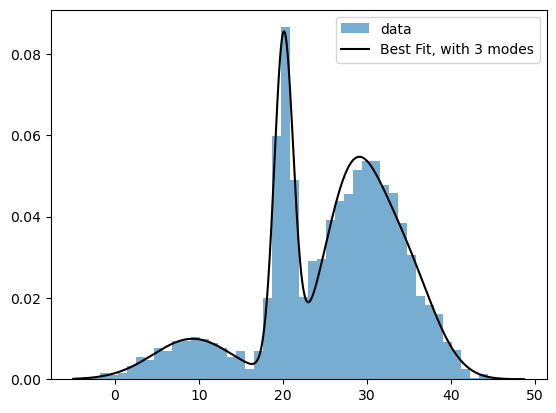

In [28]:
import matplotlib.pyplot as plt

plt.hist(data, bins=50, density=True, alpha=0.6, label = 'data')

x = np.linspace(data.min(), data.max(), 1000)
x = x[:,np.newaxis]
print(x.shape)

pdf = np.exp(best.score_samples(x))

plt.plot(x, pdf, c = 'black', label=f'Best Fit, with {np.argmin(aic)+1} modes')
plt.legend()